# Бейзлайн, подбор гиперпараметров и интерпретация модели для тайм-трекинга

## Что решаем

На предыдущем этапе была собрана недельная таблица уровня `user-week` и выделены признаки, отражающие **структуру трекинга**, а не “фактическую работу по часам”.

Здесь строится модель, которая по поведению в системе помогает выделять недели, требующие ручной проверки.

## Почему именно такой подход

В данных нет истинной разметки “отлынивает / не отлынивает”, поэтому используется proxy-target — `risk_week`.  
Он строится по признакам структуры записей и позволяет формально поставить задачу бинарной классификации.

## Что важно в оценке

Так как положительный класс редкий и ошибка пропуска подозрительной недели дороже лишней проверки, основная метрика — **F2-score**.

In [29]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import shap

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_score,
    recall_score,
    make_scorer
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
F2_SCORER = make_scorer(fbeta_score, beta=2)
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

## 1. Загрузка и подготовка данных

Ниже используется тот же raw-файл тайм-трекинга.  
Важно: в модели не используются идентификаторы пользователя и имя как признаки, потому что задача состоит в том, чтобы находить **паттерны поведения**, а не запоминать конкретных людей.

In [30]:
PATH = Path("timelogs.csv")
df = pd.read_csv(PATH, sep=";", encoding="utf-8-sig")

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

rename_map = {
    "проект": "project",
    "путь_проекта": "project_path",
    "задача": "task",
    "пользователь": "user",
    "имя": "name",
    "дата": "date",
    "часы": "hours",
    "продолжительность": "duration",
    "комментарий": "comment",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

text_cols = [c for c in ["project", "project_path", "task", "user", "name", "comment"] if c in df.columns]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["hours"] = (
    df["hours"]
    .astype("string")
    .str.replace(",", ".", regex=False)
)
df["hours"] = pd.to_numeric(df["hours"], errors="coerce")

def parse_duration_to_hours(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()
    if s in {"", "nan", "none", "null"}:
        return np.nan

    if ":" in s:
        parts = s.split(":")
        try:
            parts = [float(p) for p in parts]
        except ValueError:
            return np.nan

        if len(parts) == 3:
            hours, minutes, seconds = parts
            return hours + minutes / 60 + seconds / 3600
        if len(parts) == 2:
            hours, minutes = parts
            return hours + minutes / 60
        return np.nan

    hours_match = re.search(r"(\d+(?:\.\d+)?)\s*h", s)
    minutes_match = re.search(r"(\d+(?:\.\d+)?)\s*m", s)

    if hours_match or minutes_match:
        hours = float(hours_match.group(1)) if hours_match else 0.0
        minutes = float(minutes_match.group(1)) if minutes_match else 0.0
        return hours + minutes / 60

    num_match = re.search(r"(\d+(?:\.\d+)?)", s)
    if num_match:
        return float(num_match.group(1))

    return np.nan

if "duration" in df.columns:
    df["duration_hours"] = df["duration"].apply(parse_duration_to_hours)
else:
    df["duration_hours"] = np.nan

df["is_general_time"] = (
    df["project_path"].astype("string").str.lower().eq("mgmt/time")
)

df["weekday_num"] = df["date"].dt.dayofweek
df["weekday"] = df["date"].dt.day_name()
df["is_weekend"] = df["weekday_num"] >= 5
df["calendar_date"] = df["date"].dt.date
df["week_start"] = df["date"].dt.to_period("W-MON").dt.start_time

df["comment"] = df["comment"].fillna("")
df["comment_len"] = df["comment"].astype(str).str.len()
df["comment_is_empty"] = df["comment"].astype(str).str.strip().eq("")

df = df[df["date"].notna() & df["hours"].notna()].copy()

print("Shape after cleaning:", df.shape)
df.head(3)

Shape after cleaning: (12866, 18)


,project,project_path,task,user,name,date,hours,duration,comment,duration_hours,is_general_time,weekday_num,weekday,is_weekend,calendar_date,week_start,comment_len,comment_is_empty
0,Time Management,mgmt/time,#23695 Миху В.Д.,filberol,Vadim Mikhu,2026-05-06 12:51:00,0.5,30m,~niko Выкатил обновы и со всеми поговорил,0.5,True,2,Wednesday,False,2026-05-06,2026-05-05,41,False
1,Time Management,mgmt/time,#23695 Миху В.Д.,filberol,Vadim Mikhu,2026-05-06 12:50:00,0.5,30m,"~""tune-it"" Еще поговорил с Жуком итд",0.5,True,2,Wednesday,False,2026-05-06,2026-05-05,36,False
2,Time Management,mgmt/time,#23696 Андреев Д.С.,pride13,Dmitry Andreev,2026-05-06 12:36:00,0.5,30m,~elcom 0h30m\n\nпроверка доступности кластера ...,0.5,True,2,Wednesday,False,2026-05-06,2026-05-05,181,False


## 2. Сборка признаков на уровне `user-week`

Сначала строится недельная таблица.  
Именно такой уровень удобен для ручной проверки: одна строка — одна неделя одного пользователя.

In [31]:
df["long_track"] = (df["hours"] >= 3).astype(int)

weekly = (
    df.groupby(["user", "name", "week_start"], as_index=False)
    .agg(
        total_hours=("hours", "sum"),
        avg_hours_per_track=("hours", "mean"),
        median_hours_per_track=("hours", "median"),
        max_hours_per_track=("hours", "max"),
        tracks=("hours", "size"),
        unique_projects=("project", "nunique"),
        unique_tasks=("task", "nunique"),
        weekend_tracks=("is_weekend", "sum"),
        weekend_hours=("hours", lambda s: s[df.loc[s.index, "is_weekend"]].sum()),
        empty_comment_share=("comment_is_empty", "mean"),
        avg_comment_len=("comment_len", "mean"),
        general_tracks=("is_general_time", "sum"),
        general_hours=("hours", lambda s: s[df.loc[s.index, "is_general_time"]].sum()),
        long_track_share=("long_track", "mean"),
    )
)

task_hours = (
    df.groupby(["user", "week_start", "task"], as_index=False)["hours"]
    .sum()
)
weekly_top_task = (
    task_hours.groupby(["user", "week_start"], as_index=False)["hours"]
    .max()
    .rename(columns={"hours": "top_task_hours"})
)

project_hours = (
    df.groupby(["user", "week_start", "project"], as_index=False)["hours"]
    .sum()
)
weekly_top_project = (
    project_hours.groupby(["user", "week_start"], as_index=False)["hours"]
    .max()
    .rename(columns={"hours": "top_project_hours"})
)

weekly = weekly.merge(weekly_top_task, on=["user", "week_start"], how="left")
weekly = weekly.merge(weekly_top_project, on=["user", "week_start"], how="left")

weekly["general_share"] = weekly["general_hours"] / weekly["total_hours"].replace(0, np.nan)
weekly["weekend_share"] = weekly["weekend_hours"] / weekly["total_hours"].replace(0, np.nan)
weekly["top_task_share"] = weekly["top_task_hours"] / weekly["total_hours"].replace(0, np.nan)
weekly["top_project_share"] = weekly["top_project_hours"] / weekly["total_hours"].replace(0, np.nan)

weekly["general_share"] = weekly["general_share"].fillna(0)
weekly["weekend_share"] = weekly["weekend_share"].fillna(0)
weekly["top_task_share"] = weekly["top_task_share"].fillna(0).clip(0, 1)
weekly["top_project_share"] = weekly["top_project_share"].fillna(0).clip(0, 1)
weekly["long_track_share"] = weekly["long_track_share"].fillna(0)

weekly["is_small_week"] = (weekly["tracks"] <= 2).astype(int)

weekly = weekly[(weekly["tracks"] > 0) & (weekly["total_hours"] > 0)].copy()

weekly.head(3)

,user,name,week_start,total_hours,avg_hours_per_track,median_hours_per_track,max_hours_per_track,tracks,unique_projects,unique_tasks,...,general_tracks,general_hours,long_track_share,top_task_hours,top_project_hours,general_share,weekend_share,top_task_share,top_project_share,is_small_week
0,alexaks,Alexander Aksyonov,2025-08-26,40.0,40.0,40.0,40.0,1,1,1,...,1,40.0,1.000000,40.0,40.0,1.0,0.0,1.0,1.0,1
1,alexaks,Alexander Aksyonov,2025-09-09,6.0,2.0,2.0,3.0,3,1,3,...,0,0.0,0.333333,3.0,6.0,0.0,0.0,0.5,1.0,0
2,alexaks,Alexander Aksyonov,2025-09-16,1.0,1.0,1.0,1.0,1,1,1,...,0,0.0,0.000000,1.0,1.0,0.0,0.0,1.0,1.0,1


## 3. Построение proxy-target

Для обучения нужен бинарный таргет.  
Он строится как недельный `risk_score`, который повышается при сочетании:

- высокой доли `mgmt/time`,
- слабой заполненности комментариев,
- сильной концентрации часов в одной задаче/проекте,
- доли длинных записей,
- малой недели по числу треков.

Порог берётся по верхним 15% значений.

In [32]:
def zscore(series):
    series = series.astype(float)
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.mean()) / std

weekly["risk_score"] = (
    0.20 * zscore(weekly["long_track_share"]) +
    0.20 * zscore(weekly["top_task_share"]) +
    0.15 * zscore(weekly["top_project_share"]) +
    0.15 * zscore(weekly["empty_comment_share"]) +
    0.10 * zscore(weekly["general_share"]) +
    0.10 * zscore(weekly["weekend_share"]) +
    0.20 * zscore(weekly["is_small_week"])
)

threshold = weekly["risk_score"].quantile(0.85)
weekly["risk_week"] = (weekly["risk_score"] >= threshold).astype(int)

print("Threshold:", round(float(threshold), 4))
display(
    weekly["risk_week"]
    .value_counts()
    .rename(index={0: "normal week", 1: "manual review week"})
)
display(weekly["risk_week"].value_counts(normalize=True))

Threshold: 0.5214


risk_week
normal week           960
manual review week    172
Name: count, dtype: int64

risk_week
0    0.848057
1    0.151943
Name: proportion, dtype: float64

## 4. Разбиение на train/test

Разбиение выполняется **по времени**, а не случайно.  
Это важно, потому что случайное разбиение может смешать недели одного и того же периода между train и test и завысить качество.

Для оценки оставляется последняя часть недель по времени.

In [33]:
feature_cols = [
    "total_hours",
    "avg_hours_per_track",
    "median_hours_per_track",
    "max_hours_per_track",
    "tracks",
    "unique_projects",
    "unique_tasks",
    "weekend_tracks",
    "weekend_hours",
    "empty_comment_share",
    "avg_comment_len",
    "general_tracks",
    "general_hours",
    "general_share",
    "weekend_share",
    "top_task_share",
    "top_project_share",
    "long_track_share",
    "is_small_week",
]

X = weekly[feature_cols + ["week_start"]].copy()
y = weekly["risk_week"].copy()

unique_weeks = np.array(sorted(X["week_start"].unique()))
test_fraction_candidates = [0.20, 0.25, 0.30, 0.35]

split_found = False
for test_fraction in test_fraction_candidates:
    test_weeks = max(1, int(np.ceil(len(unique_weeks) * test_fraction)))
    cutoff = unique_weeks[-test_weeks]
    train_mask = X["week_start"] < cutoff
    test_mask = X["week_start"] >= cutoff

    y_train_candidate = y.loc[train_mask]
    y_test_candidate = y.loc[test_mask]

    if y_train_candidate.nunique() >= 2 and y_test_candidate.nunique() >= 2:
        split_found = True
        break

if not split_found:
    cutoff = unique_weeks[int(len(unique_weeks) * 0.8)]
    train_mask = X["week_start"] < cutoff
    test_mask = X["week_start"] >= cutoff

X_train = X.loc[train_mask, feature_cols].copy()
X_test = X.loc[test_mask, feature_cols].copy()
y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:")
display(y_train.value_counts(normalize=True))
print("Test class balance:")
display(y_test.value_counts(normalize=True))

Train shape: (902, 19)  Test shape: (230, 19)
Train class balance:


risk_week
0    0.853659
1    0.146341
Name: proportion, dtype: float64

Test class balance:


risk_week
0    0.826087
1    0.173913
Name: proportion, dtype: float64

## 5. Метрики

Основная метрика — **F2-score**.  
Дополнительно показываем precision и recall, чтобы понимать, за счёт чего достигнуто качество.

In [34]:
def evaluate_model(name, estimator, X_eval, y_eval):
    y_pred = estimator.predict(X_eval)
    return {
        "model": name,
        "f2": fbeta_score(y_eval, y_pred, beta=2, zero_division=0),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
    }

## 6. Бейзлайн 1: константное предсказание

Для имбалансированной задачи это важная точка сравнения.  
Если модель не превосходит такой baseline, она не добавляет ценности.

In [35]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_result = evaluate_model("Dummy most_frequent", dummy, X_test, y_test)
display(pd.DataFrame([dummy_result]))

,model,f2,precision,recall
0,Dummy most_frequent,0.0,0.0,0.0


## 7. Бейзлайн 2: логистическая регрессия

Логистическая регрессия — хороший простой baseline для табличных данных.  
Для неё нужен масштаб признаков, поэтому используется `StandardScaler`.  
Пропуски закрываются медианой.

In [36]:
logreg_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

logreg_pipe.fit(X_train, y_train)
logreg_result = evaluate_model("LogReg baseline", logreg_pipe, X_test, y_test)
display(pd.DataFrame([dummy_result, logreg_result]))

,model,f2,precision,recall
0,Dummy most_frequent,0.000000,0.000000,0.0
1,LogReg baseline,0.961538,0.833333,1.0


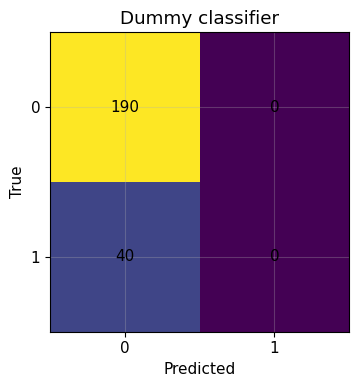

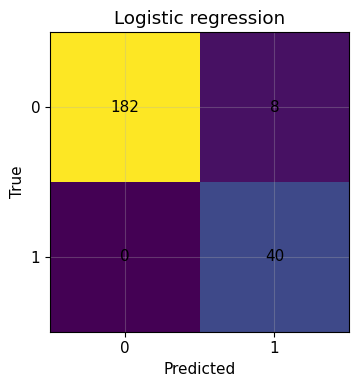

In [37]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, dummy.predict(X_test), "Dummy classifier")
plot_confusion_matrix(y_test, logreg_pipe.predict(X_test), "Logistic regression")

## 8. Более сложная модель: RandomForest

Для ансамбля деревьев не нужно масштабирование признаков, но пропуски по-прежнему заполняются медианой.  
Лес обычно хорошо работает на нелинейных зависимостях и взаимодействиях признаков.

In [38]:
rf_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced_subsample",
                n_jobs=-1,
            ),
        ),
    ]
)

param_distributions = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2", 0.7],
}

# CV по группам: одна и та же неделя не должна попадать в разные фолды
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=F2_SCORER,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train, y_train, groups=weekly.loc[train_mask, "week_start"])
print("Best CV F2:", round(search.best_score_, 4))
print("Best params:")
print(search.best_params_)

Best CV F2: 0.8441
Best params:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.7, 'model__max_depth': 5}


,model,f2,precision,recall
1,LogReg baseline,0.961538,0.833333,1.0
2,RandomForest tuned,0.882353,0.818182,0.9
0,Dummy most_frequent,0.000000,0.000000,0.0


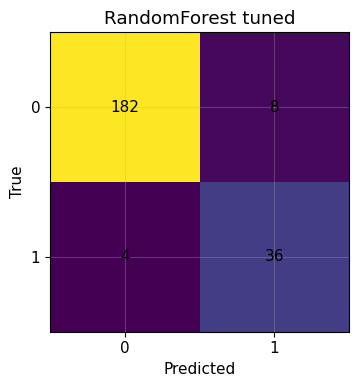

In [39]:
best_rf = search.best_estimator_
rf_result = evaluate_model("RandomForest tuned", best_rf, X_test, y_test)
results = pd.DataFrame([dummy_result, logreg_result, rf_result]).sort_values("f2", ascending=False)
display(results)

plot_confusion_matrix(y_test, best_rf.predict(X_test), "RandomForest tuned")

## 9. Глобальная интерпретация модели

Сначала смотрим permutation importance.  
Это показывает, какие признаки сильнее всего влияют на качество модели при случайной перестановке.

,feature,importance_mean,importance_std
4,tracks,0.343521,0.058998
15,top_task_share,0.282317,0.043771
6,unique_tasks,0.242637,0.034255
17,long_track_share,0.053168,0.010246
16,top_project_share,0.043687,0.021785
14,weekend_share,0.039354,0.009652
18,is_small_week,0.026616,0.006936
8,weekend_hours,0.024529,0.006228
13,general_share,0.015863,0.008697
12,general_hours,0.014860,0.004492


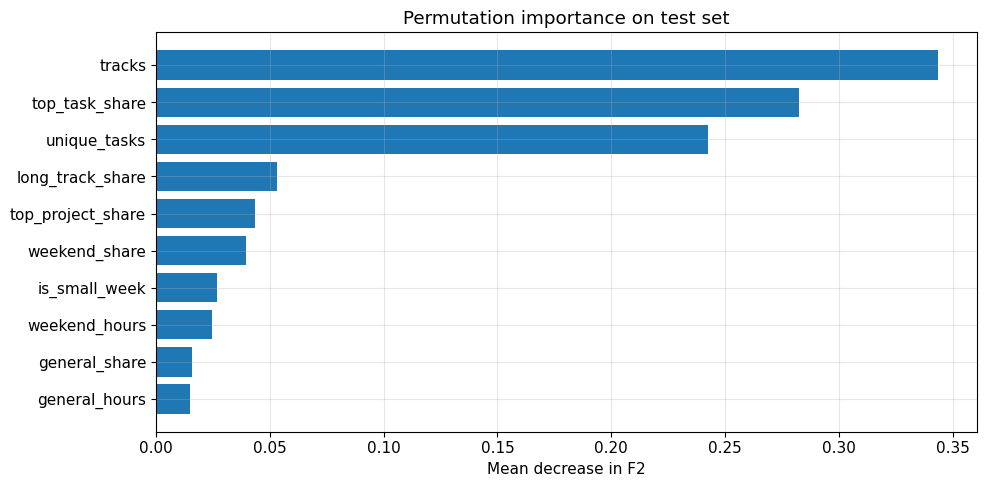

In [40]:
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring=F2_SCORER,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean": perm.importances_mean,
            "importance_std": perm.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
)

display(perm_df.head(10))

top_n = 10
plot_df = perm_df.head(top_n).sort_values("importance_mean")

plt.figure(figsize=(10, 5))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.title("Permutation importance on test set")
plt.xlabel("Mean decrease in F2")
plt.tight_layout()
plt.show()

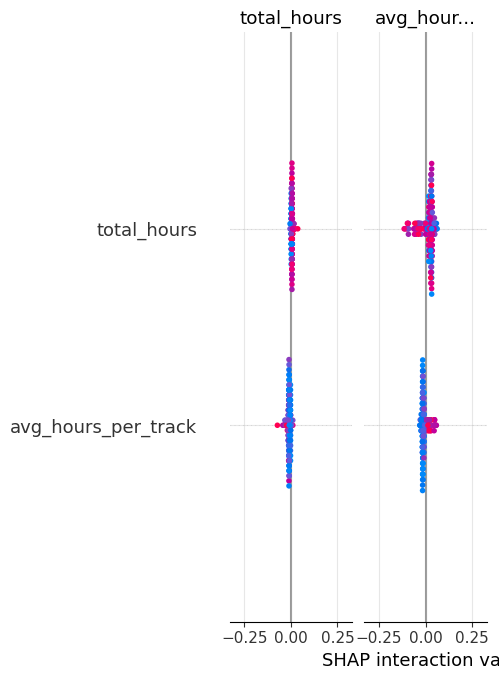

In [41]:
# SHAP summary plot
X_test_imp = pd.DataFrame(
    best_rf.named_steps["imputer"].transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

rf_model = best_rf.named_steps["model"]
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_imp)

# Поддержка разных форматов SHAP
if isinstance(shap_values, list):
    shap_class_1 = shap_values[1]
else:
    shap_class_1 = shap_values

shap.summary_plot(shap_class_1, X_test_imp, show=True)

## 10. Локальная интерпретация

Для локальной интерпретации берём один объект с высоким риском и один с низким риском и смотрим, какие признаки подтолкнули модель к такому решению.

High-risk example
True label: 1
Predicted probability: 0.9988


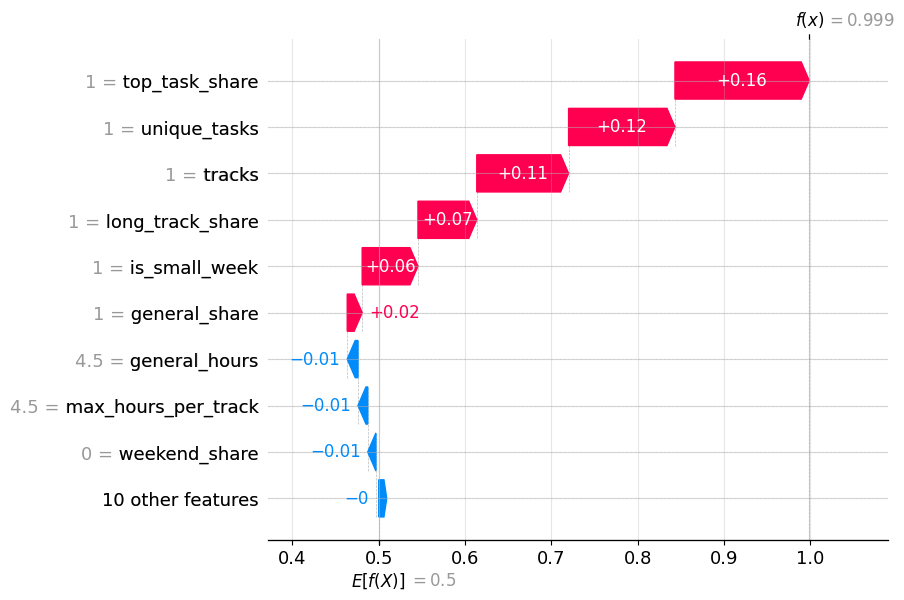

Low-risk example
True label: 0
Predicted probability: 0.0004


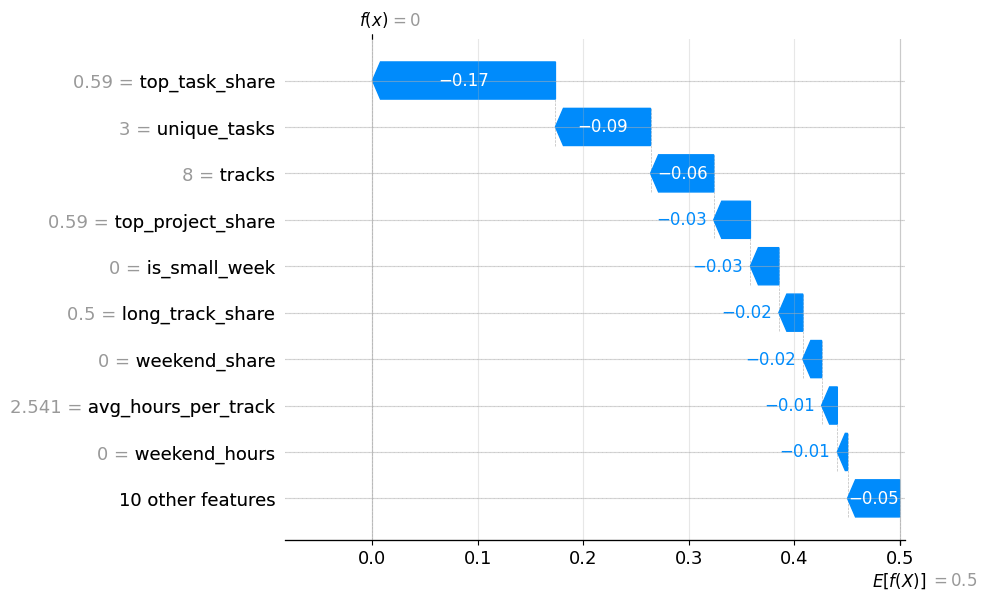

In [49]:
# Предсказания
pred_proba = best_rf.predict_proba(X_test)[:, 1]

local_df = X_test.copy()
local_df["y_true"] = y_test.values
local_df["y_pred_proba"] = pred_proba

# сортировка по "подозрительности"
local_df = local_df.sort_values("y_pred_proba", ascending=False)

high_idx = local_df.index[0]
low_idx = local_df.index[-1]

for idx, title in [
    (high_idx, "High-risk example"),
    (low_idx, "Low-risk example"),
]:
    row = X_test.loc[[idx]]

    # получаем SHAP explanation
    shap_values = explainer(row)

    # выбираем:
    # 0 — объект
    # 1 — класс "риск"
    explanation = shap_values[0, :, 1]

    print("=" * 50)
    print(title)
    print("True label:", int(local_df.loc[idx, "y_true"]))
    print("Predicted probability:", round(float(local_df.loc[idx, "y_pred_proba"]), 4))

    shap.plots.waterfall(explanation, max_display=10)

## 11. Экспертная интерпретация

По этой задаче модель должна выделять не “ленивых людей”, а недели с неаккуратным или нетипичным трекингом.

Адекватные признаки здесь:
- высокая доля `mgmt/time`,
- сильная концентрация часов в одной задаче,
- малое количество записей за неделю,
- слабое качество комментариев,
- доля длинных записей.

Если в топе оказываются именно эти признаки, то модель ведёт себя разумно.  
Если бы на первое место вышел `user` или `name`, это означало бы утечку идентичности и плохую постановку признаков.

## 12. Итог

В ноутбуке построены:
- константный baseline,
- логистическая регрессия как простой baseline,
- RandomForest с подбором гиперпараметров,
- глобальная интерпретация по permutation importance и SHAP,
- локальная интерпретация отдельных объектов.

Все разбиения сделаны по времени, `random_state` зафиксирован, а признаки выбраны так, чтобы отражать структуру трекинга, а не конкретных людей.

Модель выявляет подозрительные недели на основе низкого разнообразия задач, концентрации времени в одной активности и малого количества треков. Это соответствует ожидаемому поведению "формального" трекинга. Однако модель частично опирается на общий объём активности, что требует дополнительной нормализации признаков.